# MC Injection Trials

In [1]:
import multiprocessing as mp
from functools import partial
from dataclasses import dataclass
from itertools import product

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import DMdecay as dmd
import JWSTutils as jwst
from gnz11_split import partition_gnz11

Load GNz-11 (arxiv v1) data 

In [2]:
run_dir = "gnz11_split"
prev_config_path = F"{run_dir}/gnz11_split.toml"

In [3]:
prev_configs = dmd.prep.parse_configs(prev_config_path)
run_name = prev_configs["run"]["name"]

data = jwst.process_datafiles(prev_configs["run"]["paths"], 
                                prev_configs["system"]["res_path"])
data = partition_gnz11(data, prev_configs["run"]["lambda_min"],
                        prev_configs["run"]["lambda_split"])
for spec in data:
    dmd.prep.doppler_correction(spec, prev_configs["halo"])
    dmd.prep.add_Dfactor(spec, prev_configs["halo"])
    spec["sigma_v"] = prev_configs["halo"]["sigma_v"]

base_specset = dmd.prep.SpecSetfromList(data)

parsing gnz11_split/gnz11_split.toml
processing 2 datafiles...


In [4]:
old_rawlimits = np.loadtxt(
    F"{run_name}/{prev_configs['run']['rawlimits_filename']}")
old_is_valid = np.isfinite(old_rawlimits[:, 1])
old_masses = old_rawlimits[old_is_valid, :][:, 0]
old_lam0s = dmd.conversions.mass_to_wavelength(old_masses)
exisitng_limit_invsec = old_rawlimits[old_is_valid, :][:, 1]
old_decayrates = \
    dmd.conversions.invsec_to_fluxscale(exisitng_limit_invsec)

In [5]:
keys_for_linesearch = {
    "analysis":[
      "width_factor", 
      "padding", 
      "num_knots", 
      "chisq_step", 
      "limit_guess", 
      "max_clip_iters", 
      "clipping_factor", 
      "Ntrials", 
      "Nbins", 
      "power_threshold"],
    "halo":[ 
      "sigma_v"]}
linesearch_configs = {k:prev_configs[k1][k] 
                       for k1, l1 in keys_for_linesearch.items()
                       for k in l1
                       if k in prev_configs[k1].keys()} 
linesearch_configs["num_knots"] = 6
linesearch_configs["width_factor"] = 20
setup = dmd.linesearch.LineSearchSetup(**linesearch_configs)

In [6]:
def is_between(a, x, b):
    return (a <= x) & (x <= b)

In [15]:
n_lam_test = 800
dr_factors = [50, 50.1]
n_dr_test = 1
chisq_step = 4

In [16]:
i_to_test = np.random.choice(np.arange(old_lam0s.size), 
                             n_lam_test,
                             replace=False)
lam0s_to_test = old_lam0s[i_to_test]
r = np.random.rand(n_dr_test, n_lam_test)
decayrates_to_test = old_decayrates[i_to_test]*dr_factors[0] + \
                     old_decayrates[i_to_test]*dr_factors[1]*r
decayrates_to_test = decayrates_to_test.T

In [17]:
bf_output = np.full(decayrates_to_test.shape, np.nan)
ci_output = np.full((*decayrates_to_test.shape, 2), np.nan)

iteration = product(range(n_lam_test), range(n_dr_test))
for i_lam0, i_dr in tqdm(iteration, total=n_lam_test*n_dr_test):
        lam0 = lam0s_to_test[i_lam0]
        dr = decayrates_to_test[i_lam0, i_dr]
        # find initial chisq to scale errors
        trial_specset = base_specset.add_DM_line(dr, lam0)
        search = dmd.linesearch.LineSearcher(setup, trial_specset, lam0)
        search.fit_continuum_plus_line() 
        chisq = search.chisq(search.bf_knot_vals, search.bf_decay_rate)
        chisq_dof = chisq/search.dof_continuum_plus_line
        scaled_trial_specset = trial_specset.rescale_error(np.sqrt(chisq_dof))
        # fit scaled spectrum
        scaled_search = dmd.linesearch.LineSearcher(setup,
                                                    scaled_trial_specset, 
                                                    lam0)
        scaled_search.fit_continuum_plus_line() 
        bf_output[i_lam0, i_dr] = scaled_search.bf_decay_rate
        ci_output[i_lam0, i_dr, :] = \
            scaled_search.decayrate_ci_from_chisq(chisq_step) 

100%|██████████| 800/800 [00:23<00:00, 33.56it/s]


Text(0, 0.5, 'Fraction of lines')

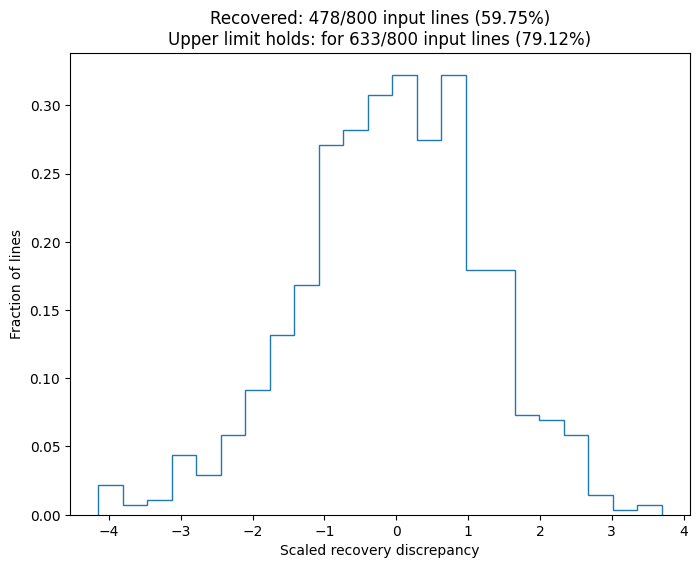

In [18]:
recovered = is_between(
    ci_output[..., 0], decayrates_to_test, ci_output[..., 1])
num_recovered = recovered.sum()
frac_recovered = num_recovered/recovered.size

upper_lim_holds = decayrates_to_test < ci_output[..., 1]
num_upper_lim_holds = upper_lim_holds.sum()
frac_upper_lim_holds = num_upper_lim_holds/upper_lim_holds.size

title_str = (
    f"Recovered: {num_recovered}/{recovered.size} " 
        f"input lines ({frac_recovered*100:0.2f}%)\n"
    f"Upper limit holds: for {num_upper_lim_holds}/{upper_lim_holds.size} " 
        f"input lines ({frac_upper_lim_holds*100:0.2f}%)"
)

width = (ci_output[..., 1] - ci_output[..., 0])/2
scaled_discrepancy = (bf_output - decayrates_to_test)/width
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(scaled_discrepancy.flatten(), histtype='step', 
        bins='auto', density=True)
ax.set_title(title_str)
ax.set_xlabel("Scaled recovery discrepancy")
ax.set_ylabel("Fraction of lines")

(800, 1)
1.7087359360586114
0.0007497258574956807


(0.1, 0.4)

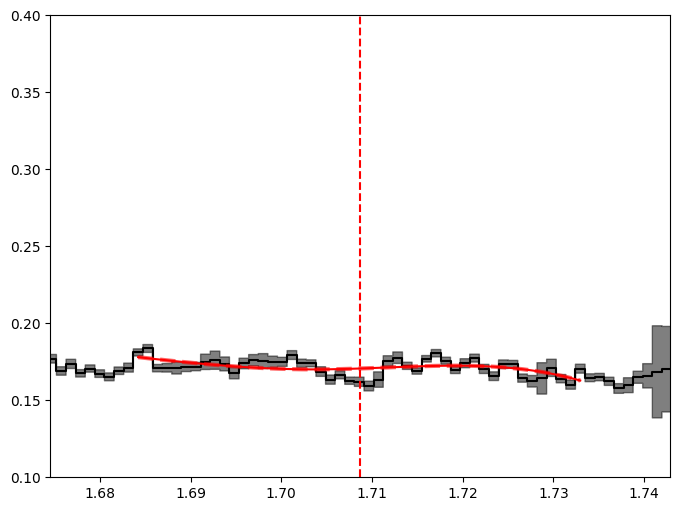

In [19]:
print(scaled_discrepancy.shape)
id_min = np.unravel_index(np.argmin(scaled_discrepancy), scaled_discrepancy.shape)
print(lam0s_to_test[id_min[0]])
print(decayrates_to_test[id_min])

search = dmd.linesearch.LineSearcher(setup, base_specset, 
                                     lam0s_to_test[id_min[0]])
bf_knot_vals, bf_decayrate= search.fit_continuum_plus_line() 
chisq_dof = chisq/search.dof_continuum_plus_line
scaled_specset = trial_specset.rescale_error(np.sqrt(chisq_dof))
model = search.spline_plus_line_model(bf_knot_vals, bf_decayrate, 
                                        search.lams_to_fit)
model_continuum_only = search.spline_plus_line_model(bf_knot_vals, 0,
                                                    search.lams_to_fit)

fig, ax = plt.subplots(figsize=(8, 6))
scaled_specset.plot(ax=ax, error_band=0.5, color='black', alpha=1)
ax.set_xlim(lam0s_to_test[id_min[0]]*np.array([0.98, 1.02]))
ax.axvline(lam0s_to_test[id_min[0]], color='red', linestyle='--')
for i_model, i_specs in enumerate(search.to_fit):
    ax.plot(search.lams_to_fit[i_specs], model[i_model], color="red")
    ax.plot(search.lams_to_fit[i_specs], model_continuum_only[i_model], 
            color="red", alpha=0.6, linewidth=3, linestyle='dashed')
ax.set_ylim(0.1, 0.4)